# Test of Gaussian Process Inverse Methods
Newton Schulz inverse vs. Numpy Inverse vs. Cholseky

In [34]:
import numpy as np
import os 
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import GP
import inverses
REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from functions import Newton_Shulz
from functions import RandomlyPivotedCholesky, forward_substitution_matrix, back_substitution_matrix

(20,)
(20,)
Using provided initial guess for Newton-Schulz
Current error = 3.6280512349209593
Current error = 3.4313707407495686
Current error = 3.2153430104461003
Current error = 2.9974346617694065
Current error = 2.821068732706018
Current error = 2.669253825285143
Current error = 2.511799972977278
Current error = 2.356859401894255
Current error = 2.1993269505808417
Current error = 2.027500778753362
Current error = 1.862835773480012
Current error = 1.760644950088502
Current error = 1.7267545147030612
Current error = 1.7162072693190864
Current error = 1.7009901550964728
Current error = 1.6725269961491573
Current error = 1.6226162684719287
Current error = 1.5460156306723962
Current error = 1.4553683779020186
Current error = 1.3846859479601856
Current error = 1.3344084808445043
Current error = 1.2588572732113905
Current error = 1.1220755340917448
Current error = 0.89504484433055
Current error = 0.5782344314251602
Current error = 0.2540500660230788
Current error = 0.05521981008684435
Curr

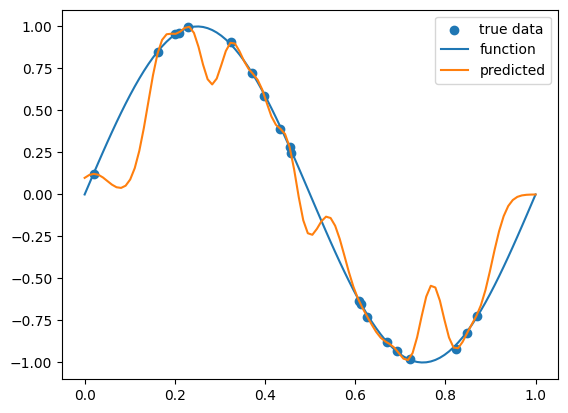

In [2]:
# make somme data
n = 20
sig = 0.01
x = np.random.rand(n)
# print(x)
y = np.sin(x* 2*np.pi) + sig*np.random.randn(n)

print(x.shape)
print(y.shape)

xth = np.linspace(0,1, 100)
yth = np.sin(xth * 2*np.pi)

# create a gaussian process object
gauss = GP.GPR(n, 1, "RBF", sig, use_ns=True, verbose=True)
# fit the gaussian process to the given data, for some sigma_f and l
gauss.fit(np.array([x]), y, theta=np.array([10, 1e-3])) # changing the hyperparameters gives you different fits
# new_x = np.random.rand(5)
new_y = gauss.predict_aft_K(xth)

fig = plt.figure()
plt.scatter(x, y, label="true data")
plt.plot(xth, yth, label="function")
plt.plot(xth, new_y, label="predicted")

plt.legend()

In [3]:
ni = inverses.NumpyInverse(True, True)
print(gauss.ker.mat.shape)
x = ni.vecSolve(gauss.ker.mat, gauss.sig, np.ones(20))
print((gauss.ker.mat+(gauss.sig**2)*np.eye(gauss.ker.mat.shape[0])) @ x)
x2 = ni.vecSolve(gauss.ker.mat, gauss.sig, np.ones(20))
ni.invalidateInverse()
x3 = ni.vecSolve(gauss.ker.mat, gauss.sig, np.ones(20))

(20, 20)
Computing inverse via numpy
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Computing inverse via numpy


In [4]:
chol = inverses.Cholesky(True, True)
x = chol.vecSolve(gauss.ker.mat, gauss.sig, np.ones(20))
print((gauss.ker.mat+(gauss.sig**2)*np.eye(gauss.ker.mat.shape[0])) @ x)

Computing cholesky factorization
forward sub has error 4.1540741810552243e-16
back sub has error 1.2208559378663128e-16
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [80]:
ns = inverses.NewtonSchulzInv(True, True, precond="None")
x = ns.vecSolve(gauss.ker.mat, gauss.sig, np.ones(20))
print((gauss.ker.mat+(gauss.sig**2)*np.eye(gauss.ker.mat.shape[0])) @ x)

No previous inverse stored
Using numpy for first inverse
(4.789637917230811e-13+0j)
Using provided initial guess for Newton-Schulz
Current error = 4.458673615196015e-10
Newton-Schulz converged at iteration 0 (error: 4.458674e-10 < 1.00e-03)
Newton_Shulz took 0.0001 seconds to execute.
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [81]:
B = np.random.randn(20,20)
pert = (1e-3)*B.T@B
x = ns.vecSolve(gauss.ker.mat + pert, gauss.sig, np.ones(20))
print((gauss.ker.mat+(gauss.sig**2)*np.eye(gauss.ker.mat.shape[0]) + pert) @ x)

-1.5711444728832666e-08
Using provided initial guess for Newton-Schulz
Current error = 0.6192239299914627
Current error = 0.28890563990871565
Current error = 0.0661713620348479
Current error = 0.0034822225681153214
Current error = 9.643512129101634e-06
Newton-Schulz converged at iteration 4 (error: 9.643512e-06 < 1.00e-03)
Newton_Shulz took 0.0001 seconds to execute.
[0.99999999 1.00000004 0.99999995 1.00000001 0.99999998 0.99999998
 1.00000001 1.00000001 0.99999999 1.00000005 1.00000001 1.
 0.99999998 1.00000001 1.         0.99999999 0.99999999 1.00000002
 1.         0.99999999]


## Note on Newton-Schulz
Newton Schulz preconditioning does not seem to help much for the simple examples I was doing. It is still in the code to play with but it currently doesn't seem to help all that much. 

In [4]:
# try optimizing
gauss.grad_dec_theta(np.array([1, 1]), alpha=1e-5)
new_y = gauss.predict_aft_K(xth)

fig = plt.figure()
plt.scatter(x, y, label="true data")
plt.plot(xth, yth, label="function")
plt.plot(xth, new_y, label="predicted")

plt.legend()

Running gradient descent with theta0 = [1 1]
Using a stopping condition of ||nabla f||^2 < 1e-05
Using a step size of 1e-05
Using provided initial guess for Newton-Schulz
Newton_Shulz exceeded the max number of iterations and has error 4.618221991874798e-07
Newton_Shulz took 0.0381 seconds to execute.
Iteration 0
theta =  [1 1]
log liklihood = -1647.0968520065298
Iteration 1
theta =  [27.76756642  0.97858221]
Using provided initial guess for Newton-Schulz
Newton_Shulz exceeded the max number of iterations and has error 0.269993347666903
Newton_Shulz took 0.0609 seconds to execute.
log liklihood = -14.252244564807391
Iteration 2
theta =  [126.59601754   0.97814563]
Using provided initial guess for Newton-Schulz
Newton_Shulz exceeded the max number of iterations and has error 136.58649696853965
Newton_Shulz took 0.0551 seconds to execute.
log liklihood = 17.89550300589387
Iteration 3
theta =  [171.4774823    0.97799889]
Using provided initial guess for Newton-Schulz
Newton_Shulz exceeded

/home/trevor/Documents/School/Grad_school/research/Newton_shulz/Newton_Shulz/gauss_proc/GP.py:209: RuntimeWarning: logm result may be inaccurate, approximate err = 2.348330503209597e-13
  logKhat = scil.logm(Khat)
/home/trevor/Documents/School/Grad_school/research/Newton_shulz/Newton_Shulz/gauss_proc/GP.py:209: RuntimeWarning: logm result may be inaccurate, approximate err = 8.280649919943448e-13
  logKhat = scil.logm(Khat)


Newton_Shulz exceeded the max number of iterations and has error 4.358898943540672
Newton_Shulz took 0.0846 seconds to execute.


/home/trevor/Documents/School/Grad_school/research/Newton_shulz/Newton_Shulz/.env/lib/python3.10/site-packages/scipy/linalg/_matfuncs.py:202: LogmExactlySingularWarning: The logm input matrix is exactly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)
/home/trevor/Documents/School/Grad_school/research/Newton_shulz/Newton_Shulz/.env/lib/python3.10/site-packages/scipy/linalg/_matfuncs.py:373: RuntimeWarning: overflow encountered in matmul
  eAw = eAw @ eAw

KeyboardInterrupt



In [ ]:
# create a gaussian process object
gauss_no_ns = GP.GPR(n, 1, "RBF", sig, use_ns=False, verbose=True)
# fit the gaussian process to the given data, for some sigma_f and l
gauss_no_ns.fit(np.array([x]), y, theta=np.array([10, 1e-3])) # changing the hyperparameters gives you different fits
# new_x = np.random.rand(5)
new_y = gauss_no_ns.predict_aft_K(xth)

In [ ]:
# try optimizing
gauss_no_ns.grad_dec_theta(np.array([1, 1]), alpha=1e-5)
new_y = gauss_no_ns.predict_aft_K(xth)

fig = plt.figure()
plt.scatter(x, y, label="true data")
plt.plot(xth, yth, label="function")
plt.plot(xth, new_y, label="predicted")

plt.legend()

Running gradient descent with theta0 = [1 1]
Using a stopping condition of ||nabla f||^2 < 1e-05
Using a step size of 1e-05
Iteration 0
theta =  [1 1]
log liklihood = -1736.2853938448663
Iteration 1
theta =  [42.82477856  0.97921211]
log liklihood = 0.4240177403501022
Iteration 2
theta =  [123.50382021   0.97881149]
log liklihood = 18.296195269316613
Iteration 3
theta =  [168.35044208   0.97867907]
log liklihood = 19.527268788694812
Iteration 4
theta =  [218.9465155    0.97862032]
log liklihood = 19.566414721606428
Iteration 5
theta =  [279.96144291   0.97858443]
log liklihood = 19.045423263239513
Iteration 6
theta =  [354.9035947    0.97858527]
log liklihood = 18.202389019587905
Iteration 7
theta =  [447.40805141   0.97849569]
log liklihood = 17.15954932188994
Iteration 8
theta =  [561.92799361   0.97830905]
log liklihood = 15.982132286046983
Iteration 9
theta =  [704.36857398   0.97859515]
log liklihood = 14.707213550806635
Iteration 10
theta =  [882.59992579   0.97935602]
log liklih

/home/trevor/Documents/School/Grad_school/research/Newton_shulz/Newton_Shulz/gauss_proc/GP.py:209: RuntimeWarning: logm result may be inaccurate, approximate err = 6.631520139596099e-13
  logKhat = scil.logm(Khat)


LinAlgError: Singular matrix